# BEE 4750 Homework 1: Introduction to Using Julia

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [137]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/4750 Cloned Repositories/bee4750-hw1-wrn25-1`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [142]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [21]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [22]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

--> I changed the line "min_value = 0" to "min_value = array[1]", the first entry in the given array.
Since all the entries in the example array_values were above 0, the code would never return anything besides 0 unless we had a negative value in the array. The function now returns the correct minimum number.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [23]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

--> This problem gives an UndefVarError because the @show line at the end asked for "average_grade" which is a variable that is only defined within the function "class_average". To fix this problem I changed the last line to "@show class_average(student_grades)" so we actually utilize the written function. Also editted the function slightly, changing the variable inside the mean() function to "grades", so that the function outputs the specific array inputted into class_average(), rather than just the average of "student_grades", the predefined array which may not be what we want to calculate the average of.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [24]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1000
counter = 0
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    if sum(passadieci()) >= 11
        counter = counter + 1
    end
end
win_prob = counter / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.502


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

--> This code gives a MethodError for several reasons, but primarily because boolean values were being assigned to array entries of an integer variable from the "outcomes[i] = (sum(passadieci()) > 11)" line. This error shows up when we call functions with none of the correct defined methods. To solve this problem I used a different process of counting the number of wins, by using an if statement and a counter variable to add one to the coutner everytime the sum of the random dice rolls was greater than or equal to 11. Then dividing this number of wins by 1,000 gives the expected probability of success.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [25]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    new_vect = vect.- m
    return  new_vect;
end
random_vect = rand(5);
@show random_vect;
new_vect = remove_mean(random_vect);
@show new_vect;

random_vect = [0.8918786505669787, 0.1985665280706047, 0.20026738210129402, 0.25279606268891297, 0.3096831614493417]
new_vect = [0.5212402935915523, -0.1720718289048217, -0.17037097487413239, -0.11784229428651344, -0.06095519552608469]


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

--> MethodError in this case refers to the line "return vect - m". vect is a vector, m is a float, and the subtraction function does not have a defined method dimension match between these two variable types. To solve this problem I used the ".-" function to subtract the mean equally from all vector entries, and I added a new vector called new_vect to take on the new updated values to simplify the code. I decreased the number of elements in the original array from 1_000 to 5 to simplify the mean calculations so I could doiuble check them. But the code works with any number of random array elements. (test)

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

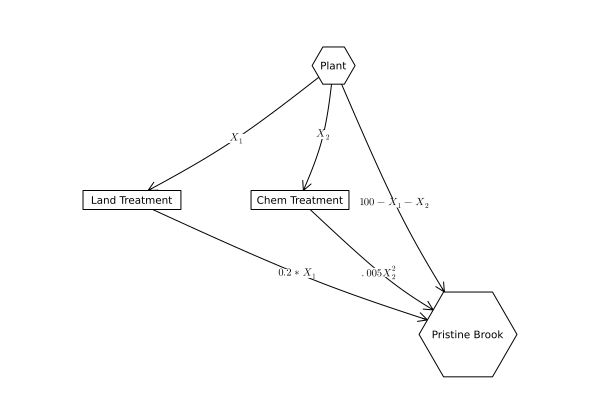

In [26]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1", (1,3) => L"X_2", (1, 4) => L"100-X_1-X_2",(2, 4) => L"0.2*X_1",(3, 4) => L".005X_2^2")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

--> In the figure above, the variables $X_1$ and $X_2$ represent the amount of wastewater disposed of on land and chemically treated respectively in ($m^3$/day) multiplied by ($1kg/m^3$), so that they instead represent the mass of YUK transferred between locations. For the sake of visual clarity I did not write out that unit conversion on each connection. 

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

The equations below come from the description of the treatment methods available to us:

-->  For the total YUK deposited, we start with a baseline of 100kg of YUK from the direct depositing strategy which we started with, then we subtract the mass of YUK from that amount based on how much wastewater we divert into the other two methods of YUK processing in the form of $X_1$ and $X_2$: Units in `kg/day`

$YUK_{tot} = 100 - 0.8X_1 - (1-0.005X_2)X_2$

--> For the total cost, we start with an initial cost of 0 since it costs nothing to directly deposit into the Pristine Brook. Then our costs increase based on the values of $X_1$ and $X_2$. Units in `$/day`

$Cost_{tot} = \frac{X_1^2}{20} + 1.50X_2$


#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [135]:
function yuk_and_cost(X_1,X_2)
    
    #adding default values with no discharge intervention
    yuk_tot = 100
    cost_tot = 0
    
    if X_1 + X_2 <= 100
        #equations for YUK and Cost
        yuk_tot = 100 - (0.8*X_1) - ((1-0.005*X_2) * X_2)
        cost_tot = (X_1^2 / 20) + (1.5*X_2)
    end
    

    return (yuk_tot, cost_tot)
end

#assigning values for YUK and Cost based on initial X1 and X2 inputs
YUK_tot, Cost_tot = yuk_and_cost(80, 20)
@show YUK_tot;
@show Cost_tot;


YUK_tot = 18.0
Cost_tot = 350.0


--> The function above incorporates the equations I derived in question 2.1 to output the YUK_tot and Cost_tot given any pair of $X_1$ and $X_2$ initial conditions. It also has an added feature to only output values for YUK_tot and Cost_tot when the values of $X_1$ and $X_2$ make sense within the context; that is, they do not sum to be more than 100, which would not be possible.

To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [101]:
#initial vectors of X_1 and X_2 pairs
X_1 = [1,2,3,4,5]
X_2 = [6,7,8,9,10]

#processing output of broadcasted function for each pairing
output = yuk_and_cost.(X_1, X_2)
YUK_tot = [out[1] for out in output]
Cost_tot = [out[2] for out in output]

@show YUK_tot;
@show Cost_tot;

YUK_tot = [93.38, 91.64500000000001, 89.91999999999999, 88.205, 86.5]
Cost_tot = [9.05, 10.7, 12.45, 14.3, 16.25]


--> The code block above uses the same yuk_and_cost function I created above and broadcasts it over two vectors which hold five different $X_1$ and $X_2$ pairings. This code setup can be easily be scaled to be used in the next question to evaluate 1,000 different $X_1$ and $X_2$ configurations.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

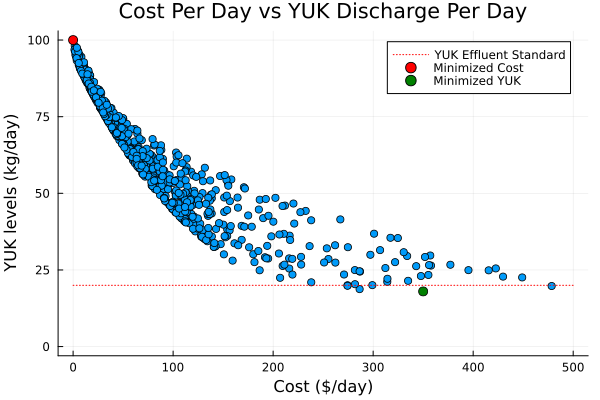

In [136]:
#create 1000 random values for X_1
d_1 = Dirichlet(1000,1)
sample_1 = rand(d_1)
X_1 = sample_1.*40000

#create 1000 random values for X_2 to pair with X_1
d_2 = Dirichlet(1000,1)
sample_2 = rand(d_2)
X_2 = sample_2.*40000

#input the 1000 X_1 and X_2 pairs into our equation function
output = yuk_and_cost.(X_1, X_2)
YUK_tot = [out[1] for out in output]
Cost_tot = [out[2] for out in output]

#plot our results
s = scatter(Cost_tot,YUK_tot, label="", title="Cost Per Day vs YUK Discharge Per Day", xlabel="Cost (\$/day)", ylabel="YUK levels (kg/day)")
xlims! = (s, 0, maximum(Cost_tot))
ylims! = (s, 0, maximum(YUK_tot))

#Add effluent line and format y-axis
plot!(s, [0,500], [20,20], label="YUK Effluent Standard", linestyle=:dot, color=:red)
plot!(s, [0,0], [0,100], label="", linealpha = 0)
scatter!(s, [0], [100], label="Minimized Cost", color=:red, markersize=5)
scatter!(s, [350], [18], label="Minimized YUK", color=:green, markersize=5)
display(s)

--> As shown in the graph above, a small few of the $X_1$ and $X_2$ pairings satisfy the YUK Effluent Standard, and all of them that do cost more than \$250/day. The tradeoff between cost and YUK discharge is very clear from this plot: In order to decrease the YUK discharge levels to a level close to the effluent standard, the cost increases exponentially. And vice versa, in order to decrease costs, the YUK discharge levels have to necessarily be increased. To find the optimal solution to this problem we could try to create a function which stores the values of any $X_1$ and $X_2$ pairings which satisfy the YUK effluent standard, then output the pairing with the lowest cost from that set. Or we can solve the problem analytically like in Problem 2.4.


#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

--> To minimize cost we can set $X_1$ and $X_2$ to 0, this will result in a cost of \$0. This strategy corresponds to funneling all the available wastewater to the direct disposal method into Pristine Brook: the free method. However this will result in $100kg$/day of YUK to be discharged into the Brook which will cause negative environmental effects, so it would not be wise to select it as a long term strategy.

--> To minimize YUK levels we can set $X_1$ to 80 and $X_2$ to 20. This will yield a YUK discharge level of $18kg$/day at a cost of \$350/day. This strategy minimizes YUK levels and meets the Effluent Standard in exchange for significantly increasing the cost. If it is economically viable for the wastewater treatment plant to afford this strategy then I would strongly recommend selecting it. This option has the treatment center treating all of its wastewater with one of the two non-direct treatment options, which means all of the wastewater is released in a controlled way. However, if the high cost is too much for the plant, there are many other choices as seen in the plot from problem 2.3, that have YUK levels between 18 and 20 kg/day while costing as low as \$250/day, which may be more satisfactory and affordable option than the true optimal solution.

## References

List any external references consulted, including classmates.

--> No external sources consulted; did not work with any other classmates.